In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [44]:
# Step No. 1 - Load the dataset
data = pd.read_csv('winequality-red.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [45]:
# Step No. 2 - Explore the dataset
print(data.shape)
# print all column names
print(data.columns.tolist())
# check for missing values
print(data.isnull().sum())

(1599, 12)
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [46]:
# Step No. 3 - Separate features and target variable
X = data.drop('quality', axis=1)
y = data['quality']

In [47]:
# Step No. 4 - Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [48]:
# Step No. 5 - Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 principal components
X_pca = pca.fit_transform(X_scaled)

In [49]:
# Step No. 6 - Visualize the PCA results
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))


[0.28173931 0.1750827 ]
0.45682201184294047


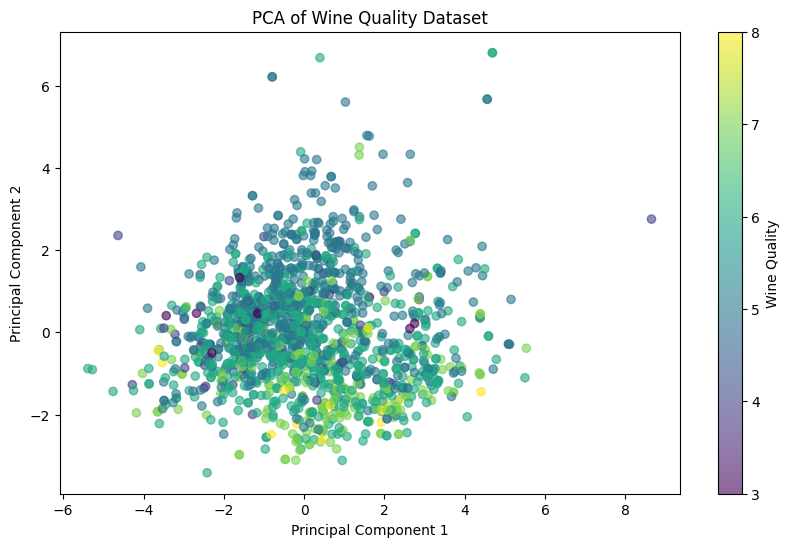

In [50]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c = y , cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Wine Quality')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Wine Quality Dataset')
plt.show()

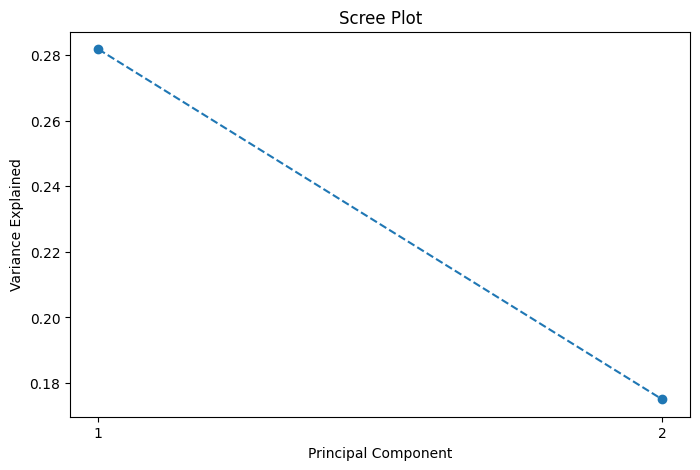

In [51]:
# scree plot (variance per component)
plt.figure(figsize=(8, 5))
plt.plot(range(1,3),pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(range(1,3))
plt.show()

In [54]:
# train a classifier on the PCA-transformed data
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy_pca = accuracy_score(y_test, y_pred)
print(f'Accuracy of Random Forest on PCA-transformed data: {accuracy_pca:.2f}')

Accuracy of Random Forest on PCA-transformed data: 0.54


In [53]:
# with original features
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
clf_orig = RandomForestClassifier(random_state=42)
clf_orig.fit(X_train_orig, y_train_orig)
y_pred_orig = clf_orig.predict(X_test_orig)
accuracy_score_orig = accuracy_score(y_test_orig, y_pred_orig)
print(f'Accuracy of Random Forest on original data: {accuracy_score_orig:.2f}')


Accuracy of Random Forest on original data: 0.65


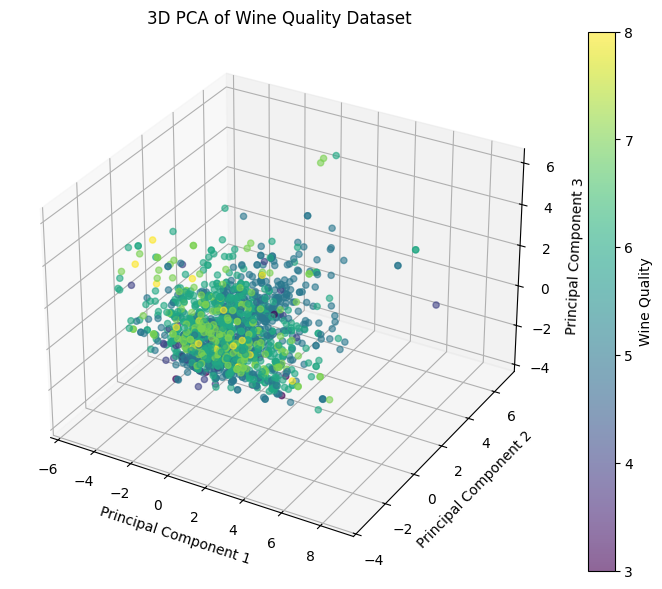

In [56]:
from mpl_toolkits.mplot3d import Axes3D
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='viridis', alpha=0.6)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA of Wine Quality Dataset')
plt.colorbar(scatter, label='Wine Quality')
plt.show()